### **CS 180 Machine Exercise 2:  Multilayer Perceptron**

**Objective**

Train and evaluate a Multilayer Perceptron (MLP) classifier on a real-world dataset using scikit-learn. You will:
- Load and explore the dataset
- Preprocess the data
- Train an MLP classifier
- Evaluate performance with metrics and visualizations


**Step 1: Import Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

**Step 2: Load and Explore the Dataset**

In [2]:
# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Explore dataset
print("Feature names:", data.feature_names)
print("Target names:", data.target_names)
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Target names: ['malignant' 'benign']
Shape of X: (569, 30)
Shape of y: (569,)


**Step 3: Split Data into Training and Test Sets**

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Step 4: Preprocess Data**
MLPs are sensitive to feature scaling, so we standardize the dataset.


In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Step 5: Train the MLP Classifier**


In [5]:
mlp = MLPClassifier(
    hidden_layer_sizes=(50),  # one hidden layer
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=50, max_iter=500, random_state=42)

**Step 6: Evaluate the Model** (20 points)
- Evaluate the model using the test set
- Show the classification report
- Display the confusion matrix

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion Matrix:
[[41  1]
 [ 4 68]]


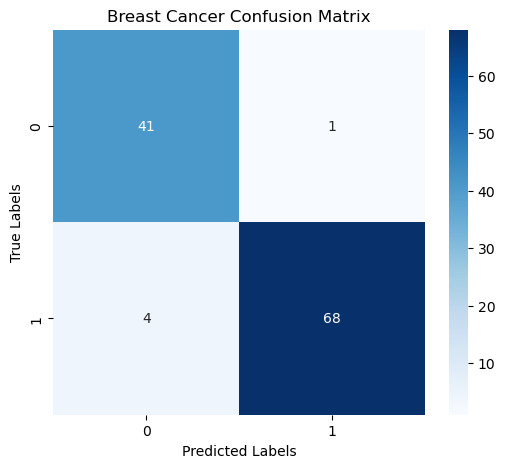

In [17]:
# Write code here

y_pred = mlp.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=mlp.classes_, yticklabels=mlp.classes_)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Breast Cancer Confusion Matrix")
plt.show()

def evaluate(model, name):
    y_pred = model.predict(X_test)
    print("{name} Classification Report:".format(name=name))
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    print("{name} Confusion Matrix:".format(name=name))
    print(cm)

    # plt.figure(figsize=(6, 5))
    # sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=mlp.classes_, yticklabels=mlp.classes_)
    # plt.xlabel("Predicted Labels")
    # plt.ylabel("True Labels")
    # plt.title("{name} Breast Cancer Confusion Matrix".format(name=name))
    # plt.show()



**Step 7: Experiment** (40 points)

- Try different hidden_layer_sizes ((100,), (50,50), (100,50,25)).
- Change the activation function ('tanh', 'logistic', 'relu').
- Adjust the learning_rate_init (0.01, 0.001, 0.0001).
- Observe how accuracy changes.


In [18]:
# Write code here
hidden_layers = [
    [100],
    [50, 50],
    [100, 50, 25]
]

activation_functions = [
    "tanh",
    "logistic",
    "relu",
]

learning_rate = [
    0.01,
    0.001,
    0.0001
]

for h in hidden_layers:
    for a in activation_functions:
        for l in learning_rate:
            mlp_experiment = MLPClassifier(
                hidden_layer_sizes=h,
                activation=a,
                solver='adam',
                max_iter=500,
                random_state=42
            )

            mlp_experiment.fit(X_train, y_train)
            name = "{hidden_layer} {activation_function} {learning_rate}".format(hidden_layer=h, activation_function=a, learning_rate=l)
            evaluate(mlp_experiment, name)

            
            
        




[100] tanh 0.01 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114

[100] tanh 0.01 Confusion Matrix:
[[41  1]
 [ 3 69]]
[100] tanh 0.001 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114

[100] tanh 0.001 Confusion Matrix:
[[41  1]
 [ 3 69]]
[100] tanh 0.0001 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
          

**Answer the following questions**



**1. How does scaling affect MLP performance?** (10 points)




Answer:

**2. Compare results between one hidden layer and multiple hidden layers.** (10 points)



Answer:

**3. Plot the loss curve (e.g. mlp.loss_curve_) of the best performing model and describe what you see.** (20 points)



In [ ]:
# Write code here

Answer:

Observations:

